In [4]:
import pandas as pd
import numpy as np
import os 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb
import time

In [5]:
# --- Define Final Data Paths and Parameters ---

# CORRECTED Base Directory for your uploaded dog data (The one that worked!)
BASE_DIR = '/kaggle/input/dogs-behaviour/formatted_vehkaoja_dogs/clip_data' 

# Parameters identified from single-file inspection:
# Columns 0 through 11 are the 12 sensor features (X, Y, Z Accel/Gyro, etc.)
SENSOR_COLUMNS = list(range(0, 12)) 

# Column 13 is the behavior code
LABEL_COLUMN_INDEX = 13

# Column 12 contains the Sampling Rate
SAMPLING_RATE_COLUMN_INDEX = 12

# Sampling Rate (f_s) identified as 23 Hz from Column 12 data
SAMPLING_RATE = 23

In [6]:
# --- Merge All Individual CSVs into a Master DataFrame ---

all_files = os.listdir(BASE_DIR)
all_dataframes = []

print(f"Starting merge of {len([f for f in all_files if f.endswith('.csv')])} individual files...")

for filename in all_files:
    if filename.endswith(".csv"):
        file_path = os.path.join(BASE_DIR, filename)
        
        # Load the file using the final, corrected parameters
        df = pd.read_csv(file_path, header=None, sep=',') 
        
        # Add a source column and append
        df['source_file'] = filename 
        all_dataframes.append(df)

# Concatenate all DataFrames
master_df = pd.concat(all_dataframes, ignore_index=True)

# Rename the critical columns for clarity in the rest of the project
master_df.rename(columns={
    SAMPLING_RATE_COLUMN_INDEX: 'sampling_rate', 
    LABEL_COLUMN_INDEX: 'behavior_label',
}, inplace=True)

# Final check of the merged data
print("\n--- Master DataFrame Ready ---")
print(f"Total Rows: {len(master_df):,}")
print(f"Target Labels Found: {master_df['behavior_label'].nunique()}")
print(master_df.head())

Starting merge of 62 individual files...

--- Master DataFrame Ready ---
Total Rows: 10,611,068
Target Labels Found: 12
          0         1         2         3         4         5           6  \
0  0.147461  1.264160 -0.108398 -0.804551  0.551318 -0.514512   88.928228   
1  0.173340  1.248047 -0.123047 -0.828442  0.606934 -0.619531   92.468267   
2  0.162598  1.187012 -0.086914 -0.813164  0.707188 -0.626387   98.388678   
3  0.216309  1.027832 -0.023926 -0.732974  0.755410 -0.457944  119.140632   
4  0.358887  0.859375 -0.149414 -0.640811  0.745703 -0.365371  180.908214   

            7          8          9         10         11  sampling_rate  \
0 -111.755378  38.085940   1.822510  35.632326 -58.405765           23.0   
1  -98.571783  21.972658   2.374268  35.003664 -50.061038           23.0   
2  -72.204594   2.807617  -3.576660  33.930666 -41.528323           23.0   
3  -43.457034 -20.385743 -16.807252  46.022342 -37.222903           23.0   
4  -33.081057 -37.902834 -34.101565  

BEHAVIOR LABEL DISTRIBUTION

Absolute Counts:
behavior_label
0.0     4533143
1.0      174926
2.0      547211
3.0      582691
4.0      653201
5.0      539418
6.0       42179
7.0      466915
8.0     1026178
9.0      488292
10.0     773879
11.0     783035
Name: count, dtype: int64

Percentage Distribution:
  Behavior 0: 42.72%
  Behavior 1: 1.65%
  Behavior 2: 5.16%
  Behavior 3: 5.49%
  Behavior 4: 6.16%
  Behavior 5: 5.08%
  Behavior 6: 0.40%
  Behavior 7: 4.40%
  Behavior 8: 9.67%
  Behavior 9: 4.60%
  Behavior 10: 7.29%
  Behavior 11: 7.38%


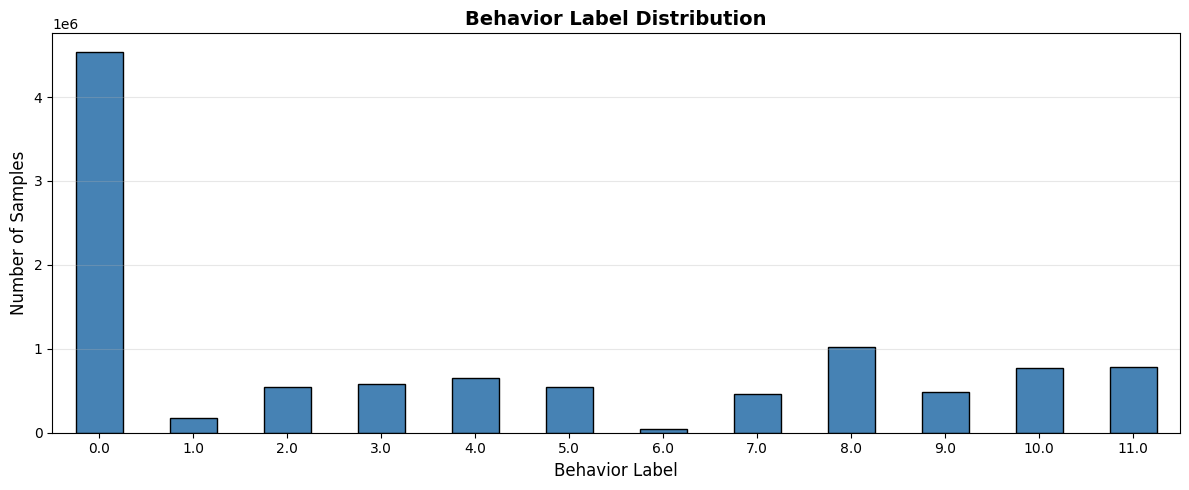

In [7]:
# Check distribution
print("=" * 70)
print("BEHAVIOR LABEL DISTRIBUTION")
print("=" * 70)

label_counts = master_df['behavior_label'].value_counts().sort_index()
print("\nAbsolute Counts:")
print(label_counts)

print("\nPercentage Distribution:")
label_percentages = (label_counts / len(master_df) * 100).round(2)
for label, pct in label_percentages.items():
    print(f"  Behavior {int(label)}: {pct:.2f}%")

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Behavior Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Behavior Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Convert labels to int (if not already)
master_df['behavior_label'] = master_df['behavior_label'].astype(int)
master_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,sampling_rate,behavior_label,source_file
0,0.147461,1.264160,-0.108398,-0.804551,0.551318,-0.514512,88.928228,-111.755378,38.085940,1.822510,35.632326,-58.405765,23.0,0,individual_23_test_2.csv
1,0.173340,1.248047,-0.123047,-0.828442,0.606934,-0.619531,92.468267,-98.571783,21.972658,2.374268,35.003664,-50.061038,23.0,0,individual_23_test_2.csv
2,0.162598,1.187012,-0.086914,-0.813164,0.707188,-0.626387,98.388678,-72.204594,2.807617,-3.576660,33.930666,-41.528323,23.0,0,individual_23_test_2.csv
3,0.216309,1.027832,-0.023926,-0.732974,0.755410,-0.457944,119.140632,-43.457034,-20.385743,-16.807252,46.022342,-37.222903,23.0,0,individual_23_test_2.csv
4,0.358887,0.859375,-0.149414,-0.640811,0.745703,-0.365371,180.908214,-33.081057,-37.902834,-34.101565,59.984135,-29.914553,23.0,0,individual_23_test_2.csv


In [9]:
def create_sliding_windows(df, window_size_sec=2, overlap_ratio=0.5, 
                          purity_threshold=0.7):
    """
    Create sliding windows from dog accelerometer data
    
    Parameters:
    -----------
    window_size_sec : float
        Window duration in seconds (2 seconds = 46 samples at 23Hz)
    overlap_ratio : float
        Overlap between windows (0.5 = 50% overlap)
    purity_threshold : float
        Minimum % of dominant behavior in window (0.7 = 70%)
    """
    window_samples = int(window_size_sec * SAMPLING_RATE)  # 2s * 23Hz = 46 samples
    step_size = int(window_samples * (1 - overlap_ratio))  # 50% overlap = 23 samples
    
    windows = []
    labels = []
    source_files = []
    
    print(f"Window Configuration:")
    print(f"  Window size: {window_size_sec}s = {window_samples} samples")
    print(f"  Step size: {step_size} samples ({(1-overlap_ratio)*100:.0f}% stride)")
    print(f"  Purity threshold: {purity_threshold*100:.0f}%")
    print(f"\nProcessing {df['source_file'].nunique()} files (dogs)...\n")
    
    # Process each dog file separately to avoid boundary mixing
    for file_idx, source_file in enumerate(df['source_file'].unique()):
        dog_data = df[df['source_file'] == source_file].reset_index(drop=True)
        dog_windows_created = 0
        
        # Slide window across this dog's data
        for i in range(0, len(dog_data) - window_samples + 1, step_size):
            window = dog_data.iloc[i:i + window_samples]
            
            # Extract 3-axis accelerometer data from FIRST sensor (columns 0,1,2)
            acc_window = window[[0, 1, 2]].values
            
            # Determine dominant behavior using majority voting
            behavior_counts = window['behavior_label'].value_counts()
            dominant_behavior = behavior_counts.idxmax()
            dominant_ratio = behavior_counts.max() / len(window)
            
            # Only keep "pure" windows where one behavior dominates
            if dominant_ratio >= purity_threshold:
                windows.append(acc_window)
                labels.append(dominant_behavior)
                source_files.append(source_file)
                dog_windows_created += 1
        
        if (file_idx + 1) % 10 == 0:
            print(f"Processed {file_idx + 1}/62 files | Total windows: {len(windows):,}")
    
    # Convert to numpy arrays
    X_raw = np.array(windows, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    
    print(f"\n All 62 files processed")
    
    return X_raw, y, np.array(source_files)

# ========== RUN WINDOWING ==========
print("=" * 70)
print("CREATING SLIDING WINDOWS")
print("=" * 70)

X_raw, y, source_files = create_sliding_windows(
    master_df, 
    window_size_sec=2, 
    overlap_ratio=0.5,
    purity_threshold=0.7
)

print("\n" + "=" * 70)
print(" WINDOWING COMPLETE")
print("=" * 70)
print(f"Total windows created: {X_raw.shape[0]:,}")
print(f"Window shape: {X_raw.shape}")
print(f"  - {X_raw.shape[0]:,} windows")
print(f"  - {X_raw.shape[1]} timesteps per window (2 sec at 23 Hz)")
print(f"  - {X_raw.shape[2]} axes (X, Y, Z)")
print(f"\nMemory usage: {X_raw.nbytes / 1024**2:.2f} MB") 

CREATING SLIDING WINDOWS
Window Configuration:
  Window size: 2s = 46 samples
  Step size: 23 samples (50% stride)
  Purity threshold: 70%

Processing 62 files (dogs)...

Processed 10/62 files | Total windows: 73,019
Processed 20/62 files | Total windows: 143,051
Processed 30/62 files | Total windows: 218,145
Processed 40/62 files | Total windows: 287,264
Processed 50/62 files | Total windows: 363,101
Processed 60/62 files | Total windows: 432,233

 All 62 files processed

 WINDOWING COMPLETE
Total windows created: 447,508
Window shape: (447508, 46, 3)
  - 447,508 windows
  - 46 timesteps per window (2 sec at 23 Hz)
  - 3 axes (X, Y, Z)

Memory usage: 235.58 MB



WINDOWED DATA - CLASS DISTRIBUTION
 Behavior  Count  Percentage
        0 191944       42.89
        8  43828        9.79
       11  32860        7.34
       10  32740        7.32
        4  27643        6.18
        3  24778        5.54
        2  23160        5.18
        5  22522        5.03
        9  20086        4.49
        7  19489        4.36
        1   6858        1.53
        6   1600        0.36


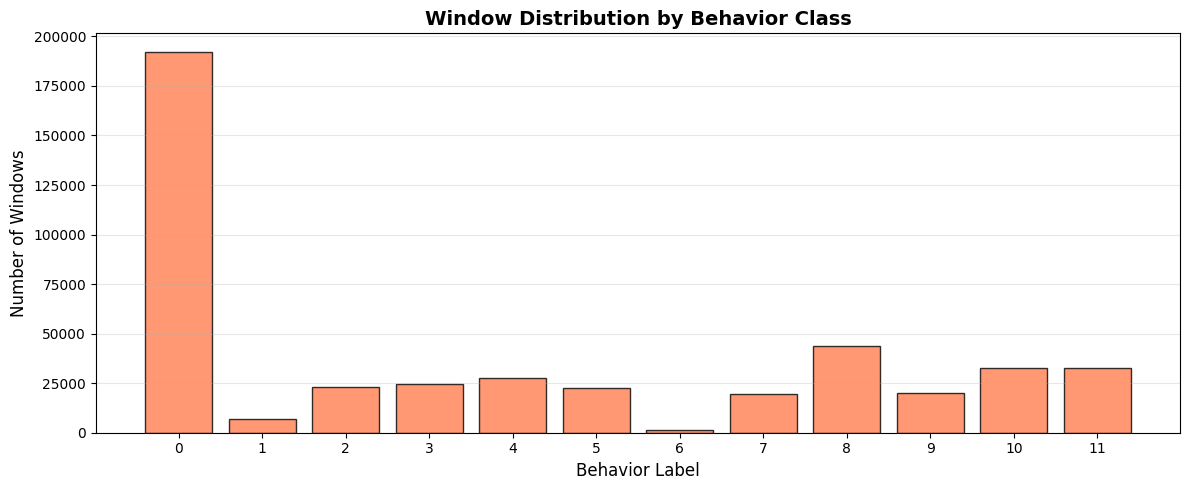

In [10]:
# Analyze windowed data distribution
print("\n" + "=" * 70)
print("WINDOWED DATA - CLASS DISTRIBUTION")
print("=" * 70)

unique_labels, label_counts = np.unique(y, return_counts=True)
window_distribution = pd.DataFrame({
    'Behavior': unique_labels.astype(int),
    'Count': label_counts,
    'Percentage': (label_counts / len(y) * 100).round(2)
}).sort_values('Count', ascending=False)

print(window_distribution.to_string(index=False))

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.bar(window_distribution['Behavior'], window_distribution['Count'], 
        color='coral', edgecolor='black', alpha=0.8)
plt.title('Window Distribution by Behavior Class', fontsize=14, fontweight='bold')
plt.xlabel('Behavior Label', fontsize=12)
plt.ylabel('Number of Windows', fontsize=12)
plt.xticks(window_distribution['Behavior'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Save raw windows for later use
np.save('/kaggle/working/X_raw_windows.npy', X_raw)
np.save('/kaggle/working/y_labels.npy', y)
np.save('/kaggle/working/source_files.npy', source_files)

print("\n Raw windows saved!")
print("  - X_raw_windows.npy")
print("  - y_labels.npy")
print("  - source_files.npy")


 Raw windows saved!
  - X_raw_windows.npy
  - y_labels.npy
  - source_files.npy


In [12]:
def extract_statistical_features(window):
    """
    Extract time-domain statistical features from a single window
    
    Input: window of shape (46, 3) - 46 timesteps, 3 axes
    Output: Dictionary of features
    """
    features = {}
    
    # Features for each axis (X, Y, Z)
    for axis_idx, axis_name in enumerate(['x', 'y', 'z']):
        axis_data = window[:, axis_idx]
        
        # Basic statistics
        features[f'{axis_name}_mean'] = np.mean(axis_data)
        features[f'{axis_name}_std'] = np.std(axis_data)
        features[f'{axis_name}_min'] = np.min(axis_data)
        features[f'{axis_name}_max'] = np.max(axis_data)
        features[f'{axis_name}_range'] = np.ptp(axis_data)  # peak-to-peak (max-min)
        features[f'{axis_name}_median'] = np.median(axis_data)
        features[f'{axis_name}_q25'] = np.percentile(axis_data, 25)
        features[f'{axis_name}_q75'] = np.percentile(axis_data, 75)
        features[f'{axis_name}_iqr'] = np.percentile(axis_data, 75) - np.percentile(axis_data, 25)
    
    # Cross-axis features (overall movement magnitude)
    magnitude = np.sqrt(np.sum(window**2, axis=1))  # Euclidean norm per timestep
    features['magnitude_mean'] = np.mean(magnitude)
    features['magnitude_std'] = np.std(magnitude)
    features['magnitude_max'] = np.max(magnitude)
    features['magnitude_min'] = np.min(magnitude)
    
    # Signal Magnitude Area (SMA) - total acceleration energy
    features['sma'] = np.sum(np.abs(window)) / len(window)
    
    # Correlations between axes
    features['corr_xy'] = np.corrcoef(window[:, 0], window[:, 1])[0, 1]
    features['corr_xz'] = np.corrcoef(window[:, 0], window[:, 2])[0, 1]
    features['corr_yz'] = np.corrcoef(window[:, 1], window[:, 2])[0, 1]
    
    return features

# ========== EXTRACT FEATURES FROM ALL WINDOWS ==========
print("=" * 70)
print("EXTRACTING FEATURES FOR XGBOOST")
print("=" * 70)
print(f"Processing {X_raw.shape[0]:,} windows...")
print("This may take a few minutes...\n")

from tqdm import tqdm  # Progress bar

feature_list = []
for i, window in enumerate(tqdm(X_raw, desc="Extracting features")):
    feature_list.append(extract_statistical_features(window))
    
    # Print progress every 100k windows
    if (i + 1) % 100000 == 0:
        print(f"  Processed {i+1:,} windows...")

X_features = pd.DataFrame(feature_list)

print("\n" + "=" * 70)
print(" FEATURE EXTRACTION COMPLETE!")
print("=" * 70)
print(f"Feature matrix shape: {X_features.shape}")
print(f"  - {X_features.shape[0]:,} windows")
print(f"  - {X_features.shape[1]} features per window")
print(f"\nMemory usage: {X_features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Sample features (first 5 rows):")
print(X_features.head())

print("\n Feature names:")
print(X_features.columns.tolist())

EXTRACTING FEATURES FOR XGBOOST
Processing 447,508 windows...
This may take a few minutes...



Extracting features:  22%|██▏       | 100096/447508 [03:14<11:04, 523.17it/s]

  Processed 100,000 windows...


Extracting features:  45%|████▍     | 200092/447508 [06:29<08:04, 510.94it/s]

  Processed 200,000 windows...


...

  Processed 300,000 windows...


Extracting features:  89%|████████▉ | 400090/447508 [13:00<01:32, 513.93it/s]

  Processed 400,000 windows...


Extracting features: 100%|██████████| 447508/447508 [14:32<00:00, 513.12it/s]



 FEATURE EXTRACTION COMPLETE!
Feature matrix shape: (447508, 35)
  - 447,508 windows
  - 35 features per window

Memory usage: 81.94 MB

 Sample features (first 5 rows):
     x_mean     x_std     x_min     x_max   x_range  x_median     x_q25  \
0  0.085895  0.362681 -0.429199  0.781738  1.210937  0.155030 -0.228028   
1 -0.311587  0.777319 -2.081543  0.781738  2.863281 -0.202148 -0.844848   
2 -0.897036  0.843735 -2.407715  0.474609  2.882324 -0.944091 -1.574341   
3 -0.567765  1.037679 -2.407715  1.118164  3.525879 -0.486084 -1.415405   
4 -0.181365  1.024493 -2.172363  1.118164  3.290527 -0.018799 -1.001221   

      x_q75     x_iqr    y_mean  ...     z_q75     z_iqr  magnitude_mean  \
0  0.328003  0.556031  1.195302  ...  0.327759  0.521118        1.815694   
1  0.391357  1.236206  1.561895  ...  0.655884  1.212036        2.978354   
2 -0.175537  1.398804  0.311163  ...  1.158447  1.649047        3.112924   
3  0.241211  1.656616  0.931258  ...  1.225586  1.431153        3.258488  

In [13]:
# Save everything for later use
print("\n" + "=" * 70)
print("SAVING PREPROCESSED DATA")
print("=" * 70)

# Save features for XGBoost
X_features.to_csv('/kaggle/working/features_xgboost.csv', index=False)
pd.DataFrame({'behavior_label': y}).to_csv('/kaggle/working/labels.csv', index=False)

# Save raw windows for CNN-LSTM (already saved earlier)
# np.save('/kaggle/working/X_raw_windows.npy', X_raw)
# np.save('/kaggle/working/y_labels.npy', y)
# np.save('/kaggle/working/source_files.npy', source_files)

print(" All data saved")
print("\n Files created:")
print("  1. features_xgboost.csv - Feature matrix for XGBoost")
print("  2. labels.csv - Behavior labels")
print("  3. X_raw_windows.npy - Raw windows for CNN-LSTM")
print("  4. y_labels.npy - Labels (numpy format)")
print("  5. source_files.npy - Source file mapping")


SAVING PREPROCESSED DATA
 All data saved

 Files created:
  1. features_xgboost.csv - Feature matrix for XGBoost
  2. labels.csv - Behavior labels
  3. X_raw_windows.npy - Raw windows for CNN-LSTM
  4. y_labels.npy - Labels (numpy format)
  5. source_files.npy - Source file mapping


In [14]:
#Quick statistical summary
print("\n" + "=" * 70)
print("FEATURE STATISTICS SUMMARY")
print("=" * 70)

print("\n Feature statistics:")
print(X_features.describe().T[['mean', 'std', 'min', 'max']])

# Check for any NaN or inf values
print(f"\n NaN values: {X_features.isna().sum().sum()}")
print(f" Inf values: {np.isinf(X_features.values).sum()}")

# If there are NaN/Inf, handle them
if X_features.isna().sum().sum() > 0 or np.isinf(X_features.values).sum() > 0:
    print("\n Cleaning data...")
    X_features = X_features.replace([np.inf, -np.inf], np.nan)
    X_features = X_features.fillna(X_features.median())
    print(" Data cleaned")


FEATURE STATISTICS SUMMARY

 Feature statistics:
                    mean       std        min        max
x_mean          0.048696  0.245633  -3.252400   6.324537
x_std           0.245735  0.485332   0.000663  10.446319
x_min          -0.441916  1.049698 -16.000000   1.309570
x_max           0.543145  1.106392  -1.022949  15.999512
x_range         0.985061  2.056069   0.002710  31.999512
x_median        0.048530  0.250629  -3.253663   7.990967
x_q25          -0.109686  0.352645  -8.812622   3.565552
x_q75           0.207161  0.416200  -1.992554  12.003906
x_iqr           0.316847  0.588691   0.000488  16.858520
y_mean         -0.153416  0.364987  -6.232932   4.254161
y_std           0.241644  0.397818   0.000721   7.855648
y_min          -0.614243  0.783231 -16.000000   0.984375
y_max           0.389381  1.172713  -0.977539  15.999512
y_range         1.003624  1.757620   0.002930  31.999512
y_median       -0.162402  0.362567  -6.020996   4.125732
y_q25          -0.315273  0.397086  -9

In [15]:
print("=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

# Get unique files
unique_files = np.unique(source_files)
print(f"Total files (dogs): {len(unique_files)}")

# Split files 80-20 (train-test)
train_files, test_files = train_test_split(
    unique_files, 
    test_size=0.2, 
    random_state=42
)

print(f"Train files: {len(train_files)} ({len(train_files)/len(unique_files)*100:.1f}%)")
print(f"Test files: {len(test_files)} ({len(test_files)/len(unique_files)*100:.1f}%)")

# Create masks for splitting data
train_mask = np.isin(source_files, train_files)
test_mask = np.isin(source_files, test_files)

# Split feature data (for XGBoost)
X_train_features = X_features[train_mask].reset_index(drop=True)
X_test_features = X_features[test_mask].reset_index(drop=True)
y_train = y[train_mask]
y_test = y[test_mask]

# Split raw windows (for CNN-LSTM)
X_train_raw = X_raw[train_mask]
X_test_raw = X_raw[test_mask]

print("\n" + "=" * 70)
print("SPLIT SUMMARY")
print("=" * 70)
print(f"\n Training Set:")
print(f"  - Windows: {len(X_train_features):,}")
print(f"  - Features shape: {X_train_features.shape}")
print(f"  - Raw windows shape: {X_train_raw.shape}")

print(f"\n Test Set:")
print(f"  - Windows: {len(X_test_features):,}")
print(f"  - Features shape: {X_test_features.shape}")
print(f"  - Raw windows shape: {X_test_raw.shape}")

# Check class distribution in train/test
print("\n Class Distribution in Train Set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for label, count in train_dist.items():
    print(f"  Behavior {int(label)}: {count:,} ({count/len(y_train)*100:.2f}%)")

print("\n Class Distribution in Test Set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for label, count in test_dist.items():
    print(f"  Behavior {int(label)}: {count:,} ({count/len(y_test)*100:.2f}%)")

TRAIN-TEST SPLIT
Total files (dogs): 62
Train files: 49 (79.0%)
Test files: 13 (21.0%)

SPLIT SUMMARY

 Training Set:
  - Windows: 349,237
  - Features shape: (349237, 35)
  - Raw windows shape: (349237, 46, 3)

 Test Set:
  - Windows: 98,271
  - Features shape: (98271, 35)
  - Raw windows shape: (98271, 46, 3)

 Class Distribution in Train Set:
  Behavior 0: 148,154 (42.42%)
  Behavior 1: 5,449 (1.56%)
  Behavior 2: 18,683 (5.35%)
  Behavior 3: 19,170 (5.49%)
  Behavior 4: 21,662 (6.20%)
  Behavior 5: 19,048 (5.45%)
  Behavior 6: 1,201 (0.34%)
  Behavior 7: 15,401 (4.41%)
  Behavior 8: 34,231 (9.80%)
  Behavior 9: 14,347 (4.11%)
  Behavior 10: 26,218 (7.51%)
  Behavior 11: 25,673 (7.35%)

 Class Distribution in Test Set:
  Behavior 0: 43,790 (44.56%)
  Behavior 1: 1,409 (1.43%)
  Behavior 2: 4,477 (4.56%)
  Behavior 3: 5,608 (5.71%)
  Behavior 4: 5,981 (6.09%)
  Behavior 5: 3,474 (3.54%)
  Behavior 6: 399 (0.41%)
  Behavior 7: 4,088 (4.16%)
  Behavior 8: 9,597 (9.77%)
  Behavior 9: 5,

In [16]:
print("\n" + "=" * 70)
print("SAVING TRAIN-TEST SPLITS")
print("=" * 70)

# Save XGBoost data (features)
X_train_features.to_csv('/kaggle/working/X_train_features.csv', index=False)
X_test_features.to_csv('/kaggle/working/X_test_features.csv', index=False)
pd.DataFrame({'behavior_label': y_train}).to_csv('/kaggle/working/y_train.csv', index=False)
pd.DataFrame({'behavior_label': y_test}).to_csv('/kaggle/working/y_test.csv', index=False)

# Save CNN-LSTM data (raw windows)
np.save('/kaggle/working/X_train_raw.npy', X_train_raw)
np.save('/kaggle/working/X_test_raw.npy', X_test_raw)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_test.npy', y_test)

# Save file splits for reference
np.save('/kaggle/working/train_files.npy', train_files)
np.save('/kaggle/working/test_files.npy', test_files)

print("\n All splits saved")
print("\n Files for XGBoost:")
print("  - X_train_features.csv")
print("  - X_test_features.csv")
print("  - y_train.csv")
print("  - y_test.csv")

print("\n Files for CNN-LSTM:")
print("  - X_train_raw.npy")
print("  - X_test_raw.npy")
print("  - y_train.npy")
print("  - y_test.npy")

print("\n Reference files:")
print("  - train_files.npy (which dogs are in train set)")
print("  - test_files.npy (which dogs are in test set)")


SAVING TRAIN-TEST SPLITS

 All splits saved

 Files for XGBoost:
  - X_train_features.csv
  - X_test_features.csv
  - y_train.csv
  - y_test.csv

 Files for CNN-LSTM:
  - X_train_raw.npy
  - X_test_raw.npy
  - y_train.npy
  - y_test.npy

 Reference files:
  - train_files.npy (which dogs are in train set)
  - test_files.npy (which dogs are in test set)


In [17]:
summary = f"""
Dataset: BEBE Dogs Behavioral Classification
================================================

RAW DATA:
  • Total files: 62 (45 unique dogs, multiple sessions)
  • Total samples: 10,611,068
  • Sampling rate: 23 Hz
  • Sensor channels: 12 (2x tri-axial accelerometer, 2x gyroscope)
  • Behaviors: 12 classes (0-11)
  
WINDOWING:
  • Window size: 2 seconds (46 samples)
  • Overlap: 50% (stride = 23 samples)
  • Purity threshold: 70% (dominant behavior must be >70%)
  • Total windows created: 447,508
  
FEATURE ENGINEERING:
  • Features per window: 35
    - Per-axis statistics (mean, std, min, max, range, median, IQR): 9 × 3 = 27
    - Magnitude features: 4
    - Signal magnitude area: 1
    - Cross-axis correlations: 3
  • Memory usage: 81.94 MB
  
TRAIN-TEST SPLIT:
  • Split method: By individual files (dogs)
  • Train set: {len(train_files)} files ({len(X_train_features):,} windows)
  • Test set: {len(test_files)} files ({len(X_test_features):,} windows)
  • Split ratio: 80-20
  
CLASS IMBALANCE:
  • Most common: Behavior 0 (42.89%)
  • Least common: Behavior 6 (0.36%)
  • Strategy: Will use weighted loss during training
  
READY FOR WEEK 2:
  ✓ XGBoost: Features extracted and saved
  ✓ CNN-LSTM: Raw windows saved
  ✓ Train-test split completed
  ✓ No data leakage (split by individual dogs)
"""

print(summary)

# Save summary to file
with open('/kaggle/working/preprocessing_summary.txt', 'w') as f:
    f.write(summary)
print("\n Summary saved to: preprocessing_summary.txt")


Dataset: BEBE Dogs Behavioral Classification

RAW DATA:
  • Total files: 62 (45 unique dogs, multiple sessions)
  • Total samples: 10,611,068
  • Sampling rate: 23 Hz
  • Sensor channels: 12 (2x tri-axial accelerometer, 2x gyroscope)
  • Behaviors: 12 classes (0-11)
  
WINDOWING:
  • Window size: 2 seconds (46 samples)
  • Overlap: 50% (stride = 23 samples)
  • Purity threshold: 70% (dominant behavior must be >70%)
  • Total windows created: 447,508
  
FEATURE ENGINEERING:
  • Features per window: 35
    - Per-axis statistics (mean, std, min, max, range, median, IQR): 9 × 3 = 27
    - Magnitude features: 4
    - Signal magnitude area: 1
    - Cross-axis correlations: 3
  • Memory usage: 81.94 MB
  
TRAIN-TEST SPLIT:
  • Split method: By individual files (dogs)
  • Train set: 49 files (349,237 windows)
  • Test set: 13 files (98,271 windows)
  • Split ratio: 80-20
  
CLASS IMBALANCE:
  • Most common: Behavior 0 (42.89%)
  • Least common: Behavior 6 (0.36%)
  • Strategy: Will use weight

In [18]:
files_to_check = [
    'X_train_features.csv',
    'X_test_features.csv', 
    'y_train.csv',
    'y_test.csv',
    'X_train_raw.npy',
    'X_test_raw.npy',
    'y_train.npy',
    'y_test.npy',
    'train_files.npy',
    'test_files.npy',
    'preprocessing_summary.txt'
]

print("\n Checking saved files:")
all_exist = True
for filename in files_to_check:
    filepath = f'/kaggle/working/{filename}'
    exists = os.path.exists(filepath)
    status = "Yes" if exists else "No"
    size = os.path.getsize(filepath) / 1024**2 if exists else 0
    print(f"{status} {filename:<30} ({size:.2f} MB)")
    if not exists:
        all_exist = False

if all_exist:
    print("\n" + "=" * 70)
    print(" WEEK 1 PREPROCESSING COMPLETE!")
    print("=" * 70)
    print("\n All files saved successfully!")
    print(" Ready to start Week 2: Model Training")
    print("\nNext steps:")
    print("  1. Train XGBoost baseline model")
    print("  2. Build and train CNN-LSTM model")
    print("  3. Compare performance metrics")
else:
    print("\n Some files are missing! Please re-run the save commands.")


📁 Checking saved files:
Yes X_train_features.csv           (160.01 MB)
Yes X_test_features.csv            (45.13 MB)
Yes y_train.csv                    (0.72 MB)
Yes y_test.csv                     (0.20 MB)
Yes X_train_raw.npy                (183.85 MB)
Yes X_test_raw.npy                 (51.73 MB)
Yes y_train.npy                    (1.33 MB)
Yes y_test.npy                     (0.37 MB)
Yes train_files.npy                (0.00 MB)
Yes test_files.npy                 (0.00 MB)
Yes preprocessing_summary.txt      (0.00 MB)

 WEEK 1 PREPROCESSING COMPLETE!

 All files saved successfully!
 Ready to start Week 2: Model Training

Next steps:
  1. Train XGBoost baseline model
  2. Build and train CNN-LSTM model
  3. Compare performance metrics


PREPROCESSING COMPLETE

XGBOOST

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

print("=" * 70)
print("MODEL TRAINING - XGBoost Baseline")
print("=" * 70)

# ========== LOAD PREPROCESSED DATA ==========
# Update this path to match your uploaded dataset name
DATA_PATH = '/kaggle/input/bebe-dogs-preprocessed'  # ← CHANGE THIS!

print("\n Loading preprocessed data...")

# Load XGBoost features
X_train = pd.read_csv(f'{DATA_PATH}/X_train_features.csv')
X_test = pd.read_csv(f'{DATA_PATH}/X_test_features.csv')
y_train = pd.read_csv(f'{DATA_PATH}/y_train.csv')['behavior_label'].values
y_test = pd.read_csv(f'{DATA_PATH}/y_test.csv')['behavior_label'].values

print("\n Data loaded")
print(f"\n Training Set: {X_train.shape[0]:,} windows, {X_train.shape[1]} features")
print(f" Test Set: {X_test.shape[0]:,} windows, {X_test.shape[1]} features")
print(f" Unique behaviors: {len(np.unique(y_train))}")

# Check class distribution
print("\n Training set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Behavior {int(label)}: {count:,} ({count/len(y_train)*100:.2f}%)")

MODEL TRAINING - XGBoost Baseline

 Loading preprocessed data...

 Data loaded

 Training Set: 349,237 windows, 35 features
 Test Set: 98,271 windows, 35 features
 Unique behaviors: 12

 Training set class distribution:
  Behavior 0: 148,154 (42.42%)
  Behavior 1: 5,449 (1.56%)
  Behavior 2: 18,683 (5.35%)
  Behavior 3: 19,170 (5.49%)
  Behavior 4: 21,662 (6.20%)
  Behavior 5: 19,048 (5.45%)
  Behavior 6: 1,201 (0.34%)
  Behavior 7: 15,401 (4.41%)
  Behavior 8: 34,231 (9.80%)
  Behavior 9: 14,347 (4.11%)
  Behavior 10: 26,218 (7.51%)
  Behavior 11: 25,673 (7.35%)


In [5]:
print("\n" + "=" * 70)
print("TRAINING XGBOOST MODEL")
print("=" * 70)

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

print("\n XGBoost Configuration:")
print("  - Objective: Multi-class classification (softmax)")
print("  - Max depth: 6")
print("  - Learning rate: 0.1")
print("  - Estimators: 100")
print("  - Class weights: Balanced (to handle imbalance)")

# Create XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=12,  # 12 behavior classes
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
    tree_method='hist'  # Faster training
)

# Train the model
print("\n Training started...")
start_time = time.time()

xgb_model.fit(
    X_train, 
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=10  # Print progress every 10 iterations
)

training_time = time.time() - start_time
print(f"\n Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


TRAINING XGBOOST MODEL

 XGBoost Configuration:
  - Objective: Multi-class classification (softmax)
  - Max depth: 6
  - Learning rate: 0.1
  - Estimators: 100
  - Class weights: Balanced (to handle imbalance)

 Training started...
[0]	validation_0-mlogloss:2.28075
[10]	validation_0-mlogloss:1.59946
[20]	validation_0-mlogloss:1.40356
[30]	validation_0-mlogloss:1.31668
[40]	validation_0-mlogloss:1.26797
[50]	validation_0-mlogloss:1.23854
[60]	validation_0-mlogloss:1.21944
[70]	validation_0-mlogloss:1.20675
[80]	validation_0-mlogloss:1.19937
[90]	validation_0-mlogloss:1.19582
[99]	validation_0-mlogloss:1.19179

 Training completed in 37.90 seconds (0.63 minutes)



CLASS IMBALANCE VERIFICATION

 Sample Weights Statistics:
 Behavior  Sample Count  Sample Weight  Total Influence
        0        148154       0.196438     29103.083333
        1          5449       5.340995     29103.083333
        2         18683       1.557731     29103.083333
        3         19170       1.518158     29103.083333
        4         21662       1.343509     29103.083333
        5         19048       1.527881     29103.083333
        6          1201      24.232376     29103.083333
        7         15401       1.889688     29103.083333
        8         34231       0.850197     29103.083333
        9         14347       2.028514     29103.083333
       10         26218       1.110042     29103.083333
       11         25673       1.133607     29103.083333


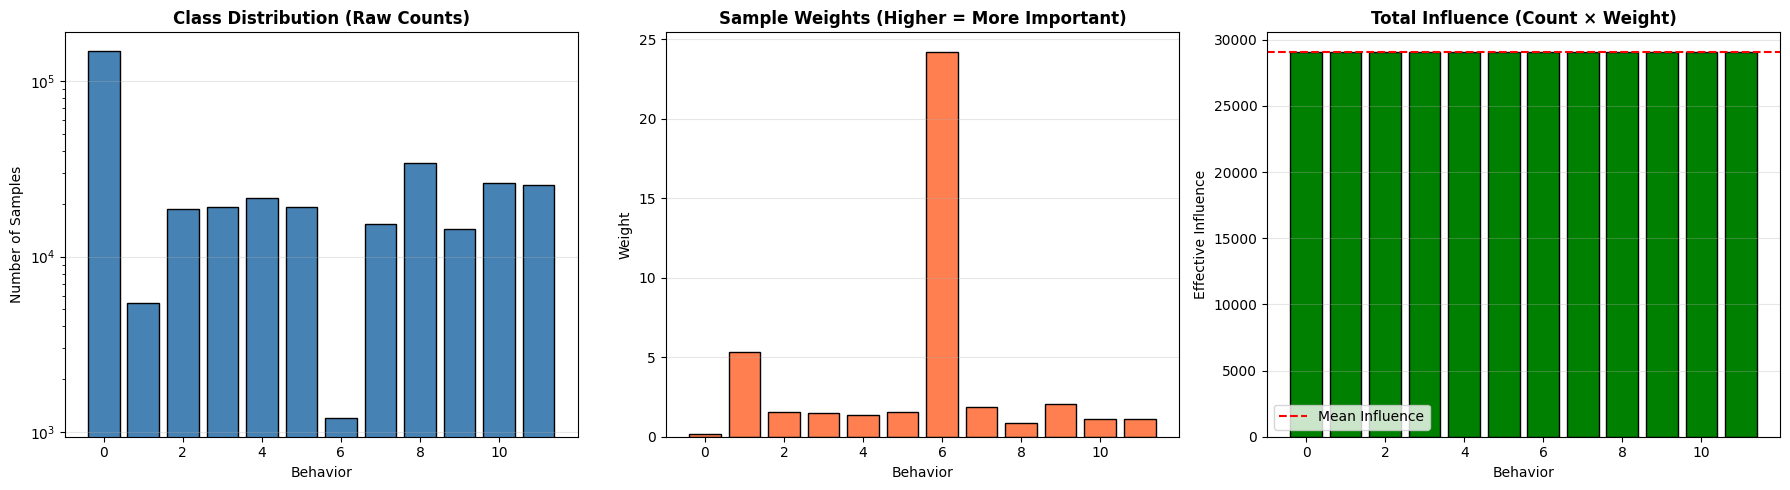


 If 'Total Influence' bars are roughly equal → Imbalance is handled correctly!


In [6]:
print("\n" + "=" * 70)
print("CLASS IMBALANCE VERIFICATION")
print("=" * 70)

# Show sample weights distribution
print("\n Sample Weights Statistics:")
weight_by_class = {}
for behavior in range(12):
    class_mask = y_train == behavior
    class_weights = sample_weights[class_mask]
    weight_by_class[behavior] = class_weights[0]  # All samples in class have same weight
    
weight_df = pd.DataFrame({
    'Behavior': range(12),
    'Sample Count': [np.sum(y_train == i) for i in range(12)],
    'Sample Weight': [weight_by_class[i] for i in range(12)],
    'Total Influence': [np.sum(y_train == i) * weight_by_class[i] for i in range(12)]
})

print(weight_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Class counts
axes[0].bar(weight_df['Behavior'], weight_df['Sample Count'], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Behavior')
axes[0].set_ylabel('Number of Samples')
axes[0].set_yscale('log')  # Log scale to show disparity
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Sample weights
axes[1].bar(weight_df['Behavior'], weight_df['Sample Weight'], color='coral', edgecolor='black')
axes[1].set_title('Sample Weights (Higher = More Important)', fontweight='bold')
axes[1].set_xlabel('Behavior')
axes[1].set_ylabel('Weight')
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Total influence (count × weight)
axes[2].bar(weight_df['Behavior'], weight_df['Total Influence'], color='green', edgecolor='black')
axes[2].set_title('Total Influence (Count × Weight)', fontweight='bold')
axes[2].set_xlabel('Behavior')
axes[2].set_ylabel('Effective Influence')
axes[2].axhline(y=weight_df['Total Influence'].mean(), color='red', 
                linestyle='--', label='Mean Influence')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_imbalance_handling.png', dpi=300)
plt.show()

print("\n If 'Total Influence' bars are roughly equal → Imbalance is handled correctly!")


In [7]:
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# Make predictions
print("\n Making predictions...")
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

print("\n PERFORMANCE METRICS:")
print("=" * 70)
print(f"{'Metric':<25} {'Train':<15} {'Test':<15}")
print("-" * 70)
print(f"{'Accuracy':<25} {train_accuracy:.4f} ({train_accuracy*100:.2f}%)  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'F1-Score (Macro)':<25} {train_f1_macro:.4f}          {test_f1_macro:.4f}")
print(f"{'F1-Score (Weighted)':<25} {train_f1_weighted:.4f}          {test_f1_weighted:.4f}")
print(f"{'Precision (Macro)':<25} {precision_score(y_train, y_train_pred, average='macro'):.4f}          {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"{'Recall (Macro)':<25} {recall_score(y_train, y_train_pred, average='macro'):.4f}          {recall_score(y_test, y_test_pred, average='macro'):.4f}")
print("=" * 70)

# Detailed classification report
print("\n DETAILED CLASSIFICATION REPORT (Test Set):")
print("=" * 70)
print(classification_report(y_test, y_test_pred, digits=4))


MODEL EVALUATION

 Making predictions...

 PERFORMANCE METRICS:
Metric                    Train           Test           
----------------------------------------------------------------------
Accuracy                  0.6680 (66.80%)  0.5676 (56.76%)
F1-Score (Macro)          0.7133          0.5843
F1-Score (Weighted)       0.6466          0.5604
Precision (Macro)         0.6539          0.5317
Recall (Macro)            0.8545          0.6992

 DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

           0     0.8321    0.3708    0.5130     43790
           1     0.4414    0.9013    0.5926      1409
           2     0.3495    0.6502    0.4546      4477
           3     0.5122    0.5200    0.5161      5608
           4     0.5767    0.6877    0.6273      5981
           5     0.3338    0.4974    0.3995      3474
           6     0.6863    0.9323    0.7906       399
           7     0.5217    0.7427    0.6129      4088
           8     0.


CONFUSION MATRIX


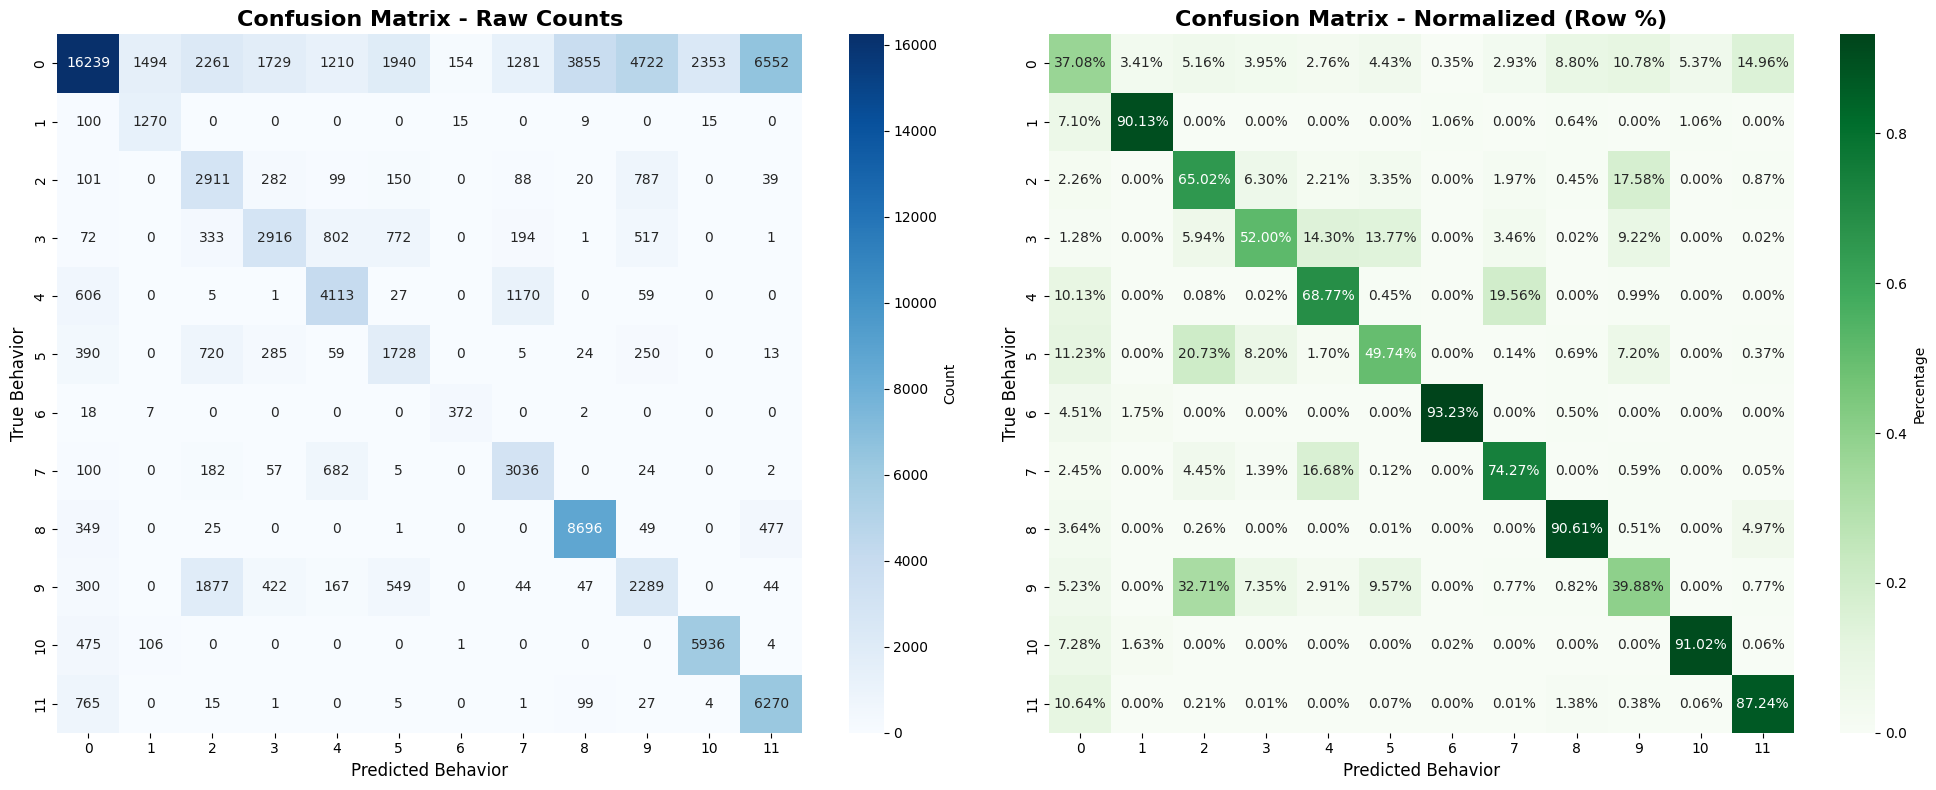


 Confusion matrix saved as: xgboost_confusion_matrix.png


In [8]:
print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Normalize confusion matrix (show percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=range(12), yticklabels=range(12), cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Behavior', fontsize=12)
axes[0].set_ylabel('True Behavior', fontsize=12)

# Normalized (percentages)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=range(12), yticklabels=range(12), cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix - Normalized (Row %)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Predicted Behavior', fontsize=12)
axes[1].set_ylabel('True Behavior', fontsize=12)

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Confusion matrix saved as: xgboost_confusion_matrix.png")


FEATURE IMPORTANCE ANALYSIS

 Top 15 Most Important Features:
      feature  importance
        x_std    0.105342
        y_q75    0.079008
        z_min    0.072490
        z_q75    0.066328
        y_q25    0.065580
        y_std    0.063606
        y_max    0.058269
magnitude_std    0.050743
      y_range    0.038917
        x_iqr    0.035948
      x_range    0.033652
     y_median    0.031800
magnitude_min    0.030028
        z_q25    0.025395
        z_std    0.025309


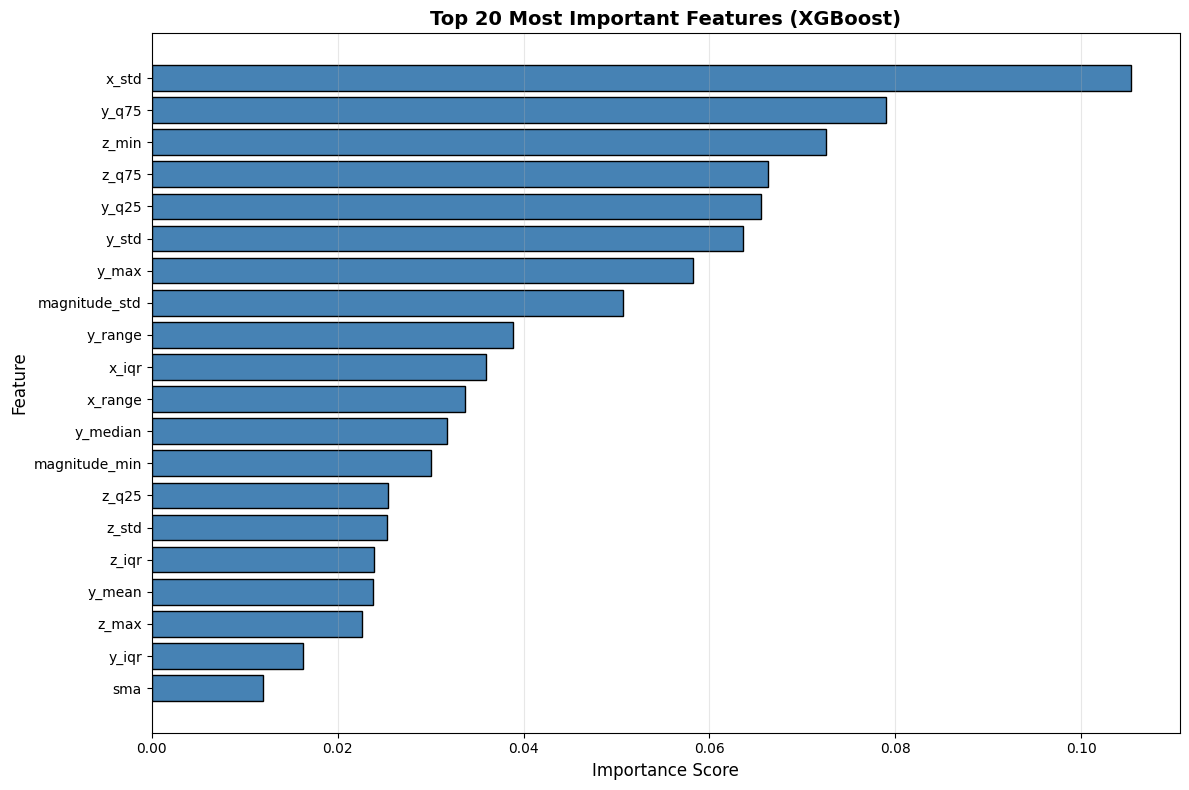


 Feature importance plot saved as: xgboost_feature_importance.png


In [9]:
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Feature importance plot saved as: xgboost_feature_importance.png")


PER-CLASS PERFORMANCE ANALYSIS

 Per-Behavior Performance:
 Behavior  Samples  Precision   Recall  F1-Score
        0    43790   0.832129 0.370838  0.513040
        1     1409   0.441432 0.901348  0.592627
        2     4477   0.349502 0.650212  0.454631
        3     5608   0.512208 0.519971  0.516061
        4     5981   0.576697 0.687678  0.627316
        5     3474   0.333784 0.497409  0.399491
        6      399   0.686347 0.932331  0.790648
        7     4088   0.521739 0.742661  0.612900
        8     9597   0.681879 0.906116  0.778166
        9     5739   0.262380 0.398850  0.316532
       10     6522   0.714492 0.910150  0.800539
       11     7187   0.467841 0.872409  0.609063


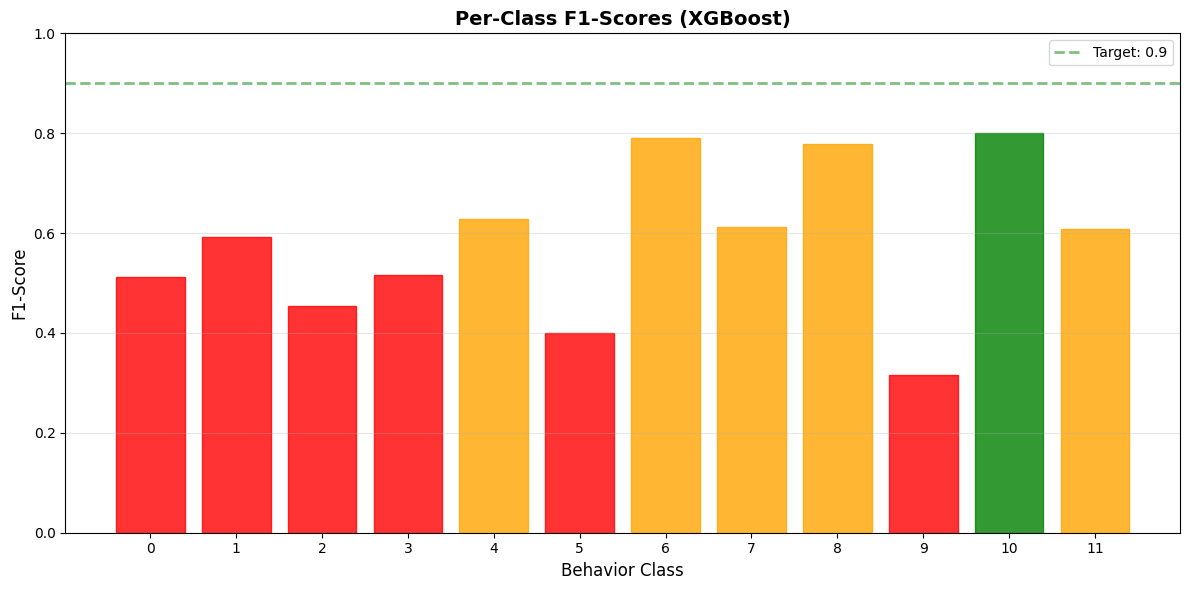


 Per-class performance plot saved as: xgboost_per_class_f1.png


In [10]:
print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 70)

# Calculate per-class metrics
per_class_f1 = f1_score(y_test, y_test_pred, average=None)
per_class_precision = precision_score(y_test, y_test_pred, average=None)
per_class_recall = recall_score(y_test, y_test_pred, average=None)

# Get support (number of samples per class)
class_counts = pd.Series(y_test).value_counts().sort_index()

# Create summary dataframe
performance_df = pd.DataFrame({
    'Behavior': range(12),
    'Samples': class_counts.values,
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1-Score': per_class_f1
})

print("\n Per-Behavior Performance:")
print(performance_df.to_string(index=False))

# Visualize per-class F1 scores
plt.figure(figsize=(12, 6))
bars = plt.bar(performance_df['Behavior'], performance_df['F1-Score'], 
               color='coral', edgecolor='black', alpha=0.8)

# Color bars: green if F1 > 0.8, orange if 0.6-0.8, red if < 0.6
for i, bar in enumerate(bars):
    f1 = performance_df.iloc[i]['F1-Score']
    if f1 >= 0.8:
        bar.set_color('green')
    elif f1 >= 0.6:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.axhline(y=0.9, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.9')
plt.xlabel('Behavior Class', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Per-Class F1-Scores (XGBoost)', fontsize=14, fontweight='bold')
plt.xticks(range(12))
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Per-class performance plot saved as: xgboost_per_class_f1.png")

In [11]:
print("\n" + "=" * 70)
print("SAVING MODEL")
print("=" * 70)

# Save model
xgb_model.save_model('xgboost_model.json')
print(" Model saved as: xgboost_model.json")

# Save performance summary
summary = {
    'model': 'XGBoost',
    'training_time_seconds': training_time,
    'test_accuracy': test_accuracy,
    'test_f1_macro': test_f1_macro,
    'test_f1_weighted': test_f1_weighted,
    'num_features': X_train.shape[1],
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

import json
with open('xgboost_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(" Performance summary saved as: xgboost_summary.json")
print("\n" + "=" * 70)
print(" XGBOOST TRAINING COMPLETE")
print("=" * 70)


SAVING MODEL
 Model saved as: xgboost_model.json
 Performance summary saved as: xgboost_summary.json

 XGBOOST TRAINING COMPLETE


CNN-LSTM

2025-12-28 10:45:47.106094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766918747.343309      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766918747.415784      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

 Trainable params: 1,031,756 (3.94 MB)

 Non-trainable params: 1,792 (7.00 KB)


 Total Parameters: 1,033,548

COMPILING MODEL

 Model compiled!
  - Optimizer: Adam
  - Learning Rate: 0.0005 (reduced from 0.001)
  - Loss: Sparse Categorical Crossentropy

CONFIGURING CALLBACKS

 Callbacks configured:
  • Learning Rate Scheduler: Gradual decay (0.96^epoch)
  • Early Stopping: Patience = 20 epochs
  • Model Checkpoint: Save best model
  • TensorBoard: Log training metrics

TRAINING ENHANCED CNN-LSTM MODEL

 Training Configuration:
  - Batch size: 64 (smaller for better gradients)
  - Max epochs: 100
  - Validation split: 15%
  - Class weights: Enabled (balanced)
  - Initial learning rate: 0.0005

 Data split:
  - Training: 296,851 windows
  - Validation: 52,385 windows
  - Test: 98,271 windows

 Starting training...

Epoch 1: LearningRateScheduler setting learning rate to 0.0005.
Epoch 1/100


I0000 00:00:1766918774.238653     111 cuda_dnn.cc:529] Loaded cuDNN version 90300


4639/4639 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4955 - loss: 1.3997
Epoch 1: val_loss improved from inf to 0.89874, saving model to cnn_lstm_best_model_v2.keras
4639/4639 ━━━━━━━━━━━━━━━━━━━━ 92s 18ms/step - accuracy: 0.4955 - loss: 1.3996 - val_accuracy: 0.6259 - val_loss: 0.8987 - learning_rate: 5.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.00048.
Epoch 2/100
4636/4639 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6504 - loss: 0.8889
Epoch 2: val_loss did not improve from 0.89874
4639/4639 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.6504 - loss: 0.8889 - val_accuracy: 0.6373 - val_loss: 0.9871 - learning_rate: 4.8000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0004608.
Epoch 3/100
4638/4639 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7179 - loss: 0.7583
Epoch 3: val_loss improved from 0.89874 to 0.89215, saving model to cnn_lstm_best_model_v2.keras
4639/4639 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.7179 - loss: 0

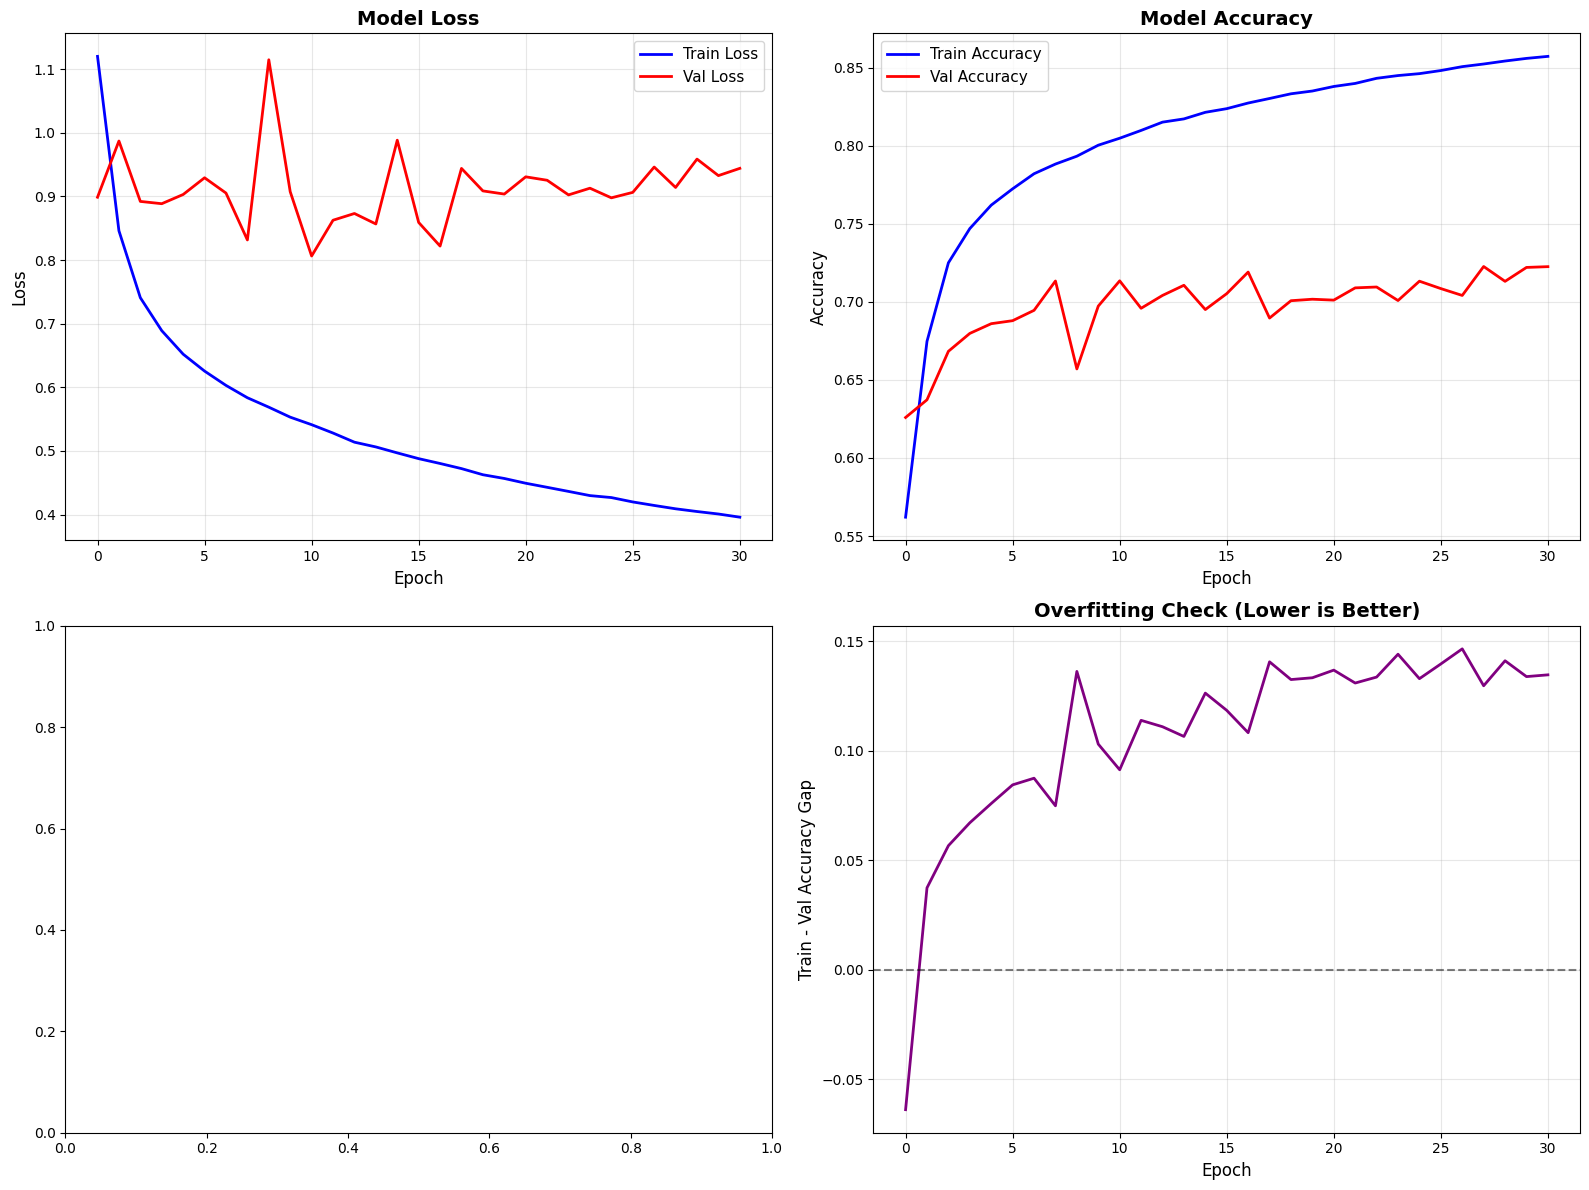


 Training history saved

EVALUATING ON TEST SET

 Making predictions...

 PERFORMANCE METRICS:
Metric                         Train           Test            vs XGBoost     
--------------------------------------------------------------------------------
Accuracy                       0.7936      0.6826      +0.1150
F1-Score (Macro)               0.7816      0.6605      +0.0762
F1-Score (Weighted)            0.7923      0.6865      +0.1261
Precision (Macro)              0.7647      0.6560      +0.1243
Recall (Macro)                 0.8063      0.6802      -0.0190

 SUCCESS! CNN-LSTM beats XGBoost by 20.26%!

 DETAILED CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

           0     0.7757    0.6937    0.7324     43790
           1     0.7819    0.7686    0.7752      1409
           2     0.2909    0.5477    0.3800      4477
           3     0.6778    0.5706    0.6196      5608
           4     0.6732    0.7136    0.6928      5981
           5  

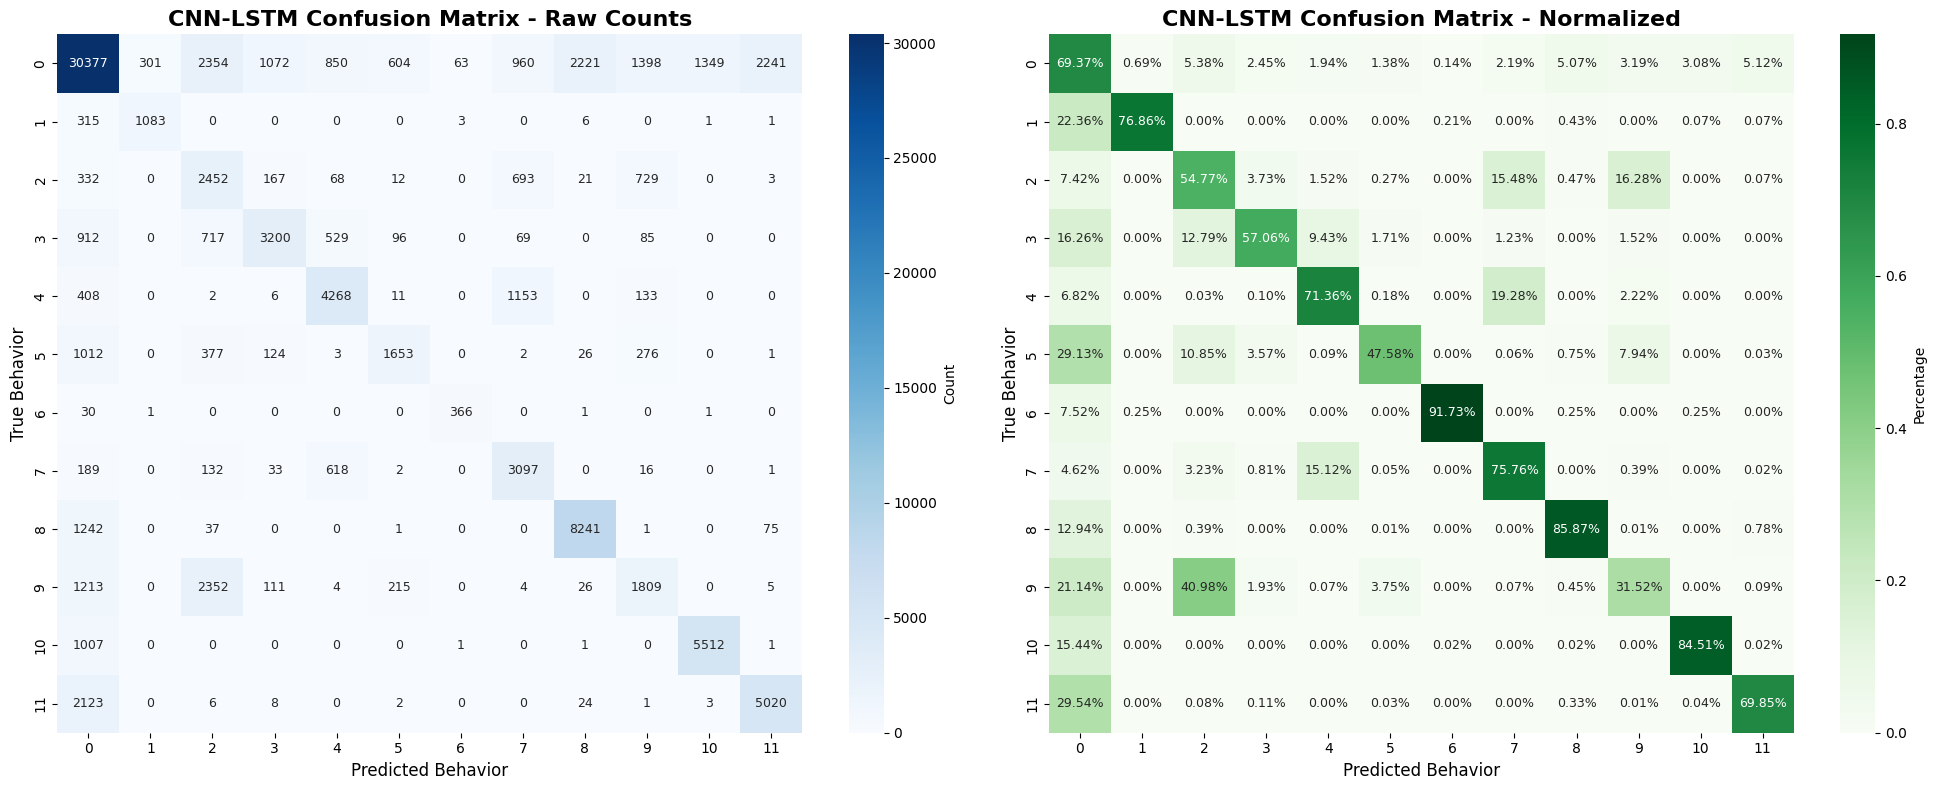


 Confusion matrix saved

🔍 Top Confusion Pairs:
 True  Predicted  Count Percent
    0          2   2354    5.4%
    9          2   2352   41.0%
    0         11   2241    5.1%
    0          8   2221    5.1%
   11          0   2123   29.5%
    0          9   1398    3.2%
    0         10   1349    3.1%
    8          0   1242   12.9%
    9          0   1213   21.1%
    4          7   1153   19.3%

PER-CLASS PERFORMANCE

 Per-Behavior Performance:
 Behavior  Samples  Precision   Recall  F1-Score
        0    43790   0.775715 0.693697  0.732417
        1     1409   0.781949 0.768630  0.775233
        2     4477   0.290900 0.547688  0.379978
        3     5608   0.677822 0.570613  0.619615
        4     5981   0.673186 0.713593  0.692801
        5     3474   0.636749 0.475820  0.544646
        6      399   0.845266 0.917293  0.879808
        7     4088   0.518066 0.757583  0.615339
        8     9597   0.779881 0.858706  0.817397
        9     5739   0.406700 0.315212  0.355159
       10

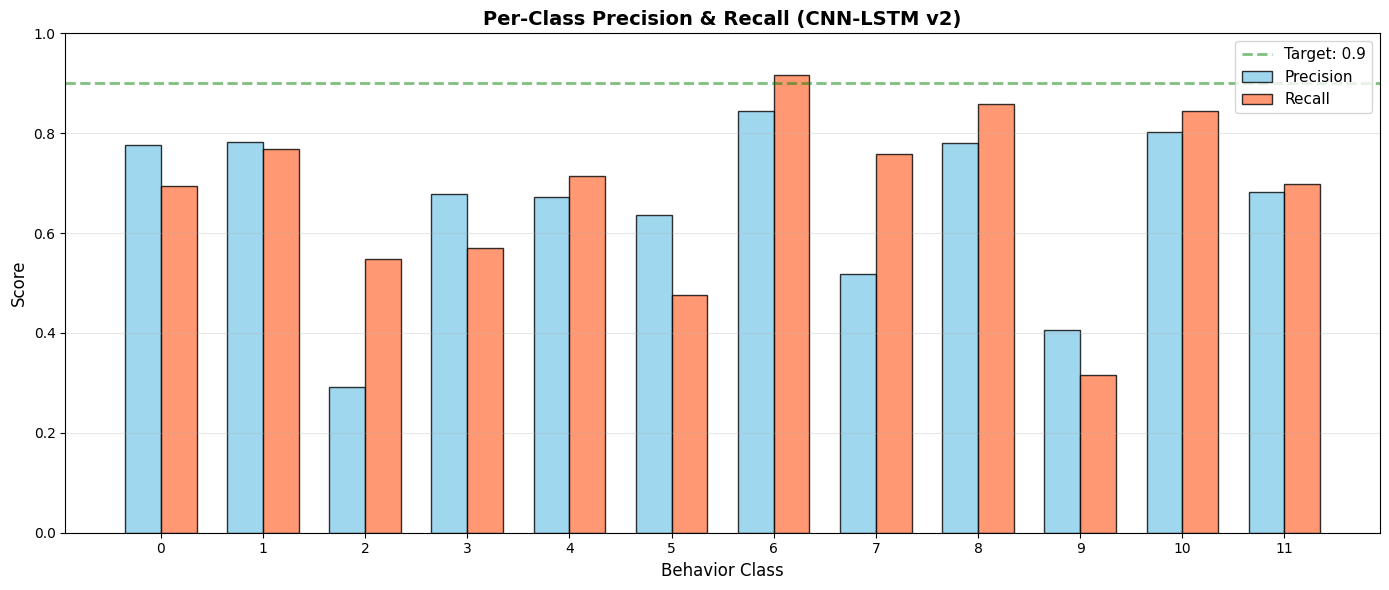


 Per-class performance saved

SAVING ALL RESULTS
 Model saved: cnn_lstm_model_v2.keras
 Predictions saved
 Confusion matrix saved
 Results saved: cnn_lstm_v2_results.json
 Per-class performance saved
 Training history saved

 CNN-LSTM V2 TRAINING COMPLETE!

 Files saved:
  • cnn_lstm_model_v2.keras
  • cnn_lstm_v2_results.json
  • cnn_lstm_v2_y_test_pred.npy
  • cnn_lstm_v2_confusion_matrix.npy
  • cnn_lstm_v2_per_class_performance.csv
  • cnn_lstm_v2_training_history.csv
  • cnn_lstm_v2_training_history.png
  • cnn_lstm_v2_confusion_matrix.png
  • cnn_lstm_v2_per_class_metrics.png

FINAL SUMMARY

 Test Accuracy: 0.6826 (68.26%)
 Test F1 (Macro): 0.6605

 Comparison with XGBoost:
   XGBoost Accuracy: 56.76%
   CNN-LSTM Accuracy: 68.26%
   Improvement: +11.50%

   XGBoost F1: 0.5843
   CNN-LSTM F1: 0.6605
   Improvement: +0.0762

 EXCELLENT! Model performance is strong!

 Ready for Week 3: Model Comparison & SHAP Explainability!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import time

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("CNN-LSTM OPTIMIZED MODEL (V2) - WITH ALL FIXES")
print("=" * 80)

# ========================================================================
# STEP 1: LOAD DATA
# ========================================================================
print("\n Loading preprocessed data...")

DATA_PATH = '/kaggle/input/bebe-dogs-preprocessed'  # ← UPDATE IF NEEDED

X_train_raw = np.load(f'{DATA_PATH}/X_train_raw.npy')
X_test_raw = np.load(f'{DATA_PATH}/X_test_raw.npy')
y_train = np.load(f'{DATA_PATH}/y_train.npy')
y_test = np.load(f'{DATA_PATH}/y_test.npy')

print(f"\n Data loaded!")
print(f"   Training: {X_train_raw.shape[0]:,} windows")
print(f"   Test: {X_test_raw.shape[0]:,} windows")
print(f"   Window shape: ({X_train_raw.shape[1]} timesteps, {X_train_raw.shape[2]} axes)")

# ========================================================================
# STEP 2: CALCULATE CLASS WEIGHTS
# ========================================================================
print("\n Computing class weights for imbalanced data...")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n Class weights:")
for i in range(12):
    samples = np.sum(y_train == i)
    print(f"  Behavior {i}: {class_weights_dict[i]:.3f} ({samples:,} samples)")

# ========================================================================
# STEP 3: BUILD ENHANCED CNN-LSTM MODEL
# ========================================================================
print("\n" + "=" * 80)
print("BUILDING ENHANCED CNN-LSTM ARCHITECTURE")
print("=" * 80)

def create_enhanced_cnn_lstm(input_shape=(46, 3), num_classes=12):
    """
    Enhanced CNN-LSTM with:
    - Deeper architecture
    - More filters
    - Residual-style connections
    - Better regularization
    """
    
    model = models.Sequential(name='Enhanced_CNN_LSTM')
    
    # ========== CONV BLOCK 1 ==========
    model.add(layers.Conv1D(
        filters=128,
        kernel_size=7,
        activation='relu',
        padding='same',
        input_shape=input_shape,
        name='conv1d_1a'
    ))
    model.add(layers.BatchNormalization(name='bn_1a'))
    
    model.add(layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
        padding='same',
        name='conv1d_1b'
    ))
    model.add(layers.BatchNormalization(name='bn_1b'))
    model.add(layers.MaxPooling1D(pool_size=2, name='pool_1'))
    model.add(layers.Dropout(0.3, name='dropout_1'))
    
    # ========== CONV BLOCK 2 ==========
    model.add(layers.Conv1D(
        filters=256,
        kernel_size=5,
        activation='relu',
        padding='same',
        name='conv1d_2a'
    ))
    model.add(layers.BatchNormalization(name='bn_2a'))
    
    model.add(layers.Conv1D(
        filters=256,
        kernel_size=3,
        activation='relu',
        padding='same',
        name='conv1d_2b'
    ))
    model.add(layers.BatchNormalization(name='bn_2b'))
    model.add(layers.MaxPooling1D(pool_size=2, name='pool_2'))
    model.add(layers.Dropout(0.3, name='dropout_2'))
    
    # ========== LSTM LAYERS ==========
    model.add(layers.Bidirectional(
        layers.LSTM(128, return_sequences=True),
        name='bilstm_1'
    ))
    model.add(layers.Dropout(0.4, name='dropout_3'))
    
    model.add(layers.Bidirectional(
        layers.LSTM(64, return_sequences=False),
        name='bilstm_2'
    ))
    model.add(layers.Dropout(0.4, name='dropout_4'))
    
    # ========== DENSE LAYERS ==========
    model.add(layers.Dense(128, activation='relu', name='dense_1'))
    model.add(layers.BatchNormalization(name='bn_3'))
    model.add(layers.Dropout(0.5, name='dropout_5'))
    
    model.add(layers.Dense(64, activation='relu', name='dense_2'))
    model.add(layers.Dropout(0.4, name='dropout_6'))
    
    # ========== OUTPUT ==========
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    
    return model

# Create model
model = create_enhanced_cnn_lstm(input_shape=(46, 3), num_classes=12)

print("\n Model Architecture Summary:")
model.summary()

total_params = model.count_params()
print(f"\n Total Parameters: {total_params:,}")

# ========================================================================
# STEP 4: COMPILE MODEL (LOWER LEARNING RATE)
# ========================================================================
print("\n" + "=" * 80)
print("COMPILING MODEL")
print("=" * 80)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # ← Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n Model compiled!")
print("  - Optimizer: Adam")
print("  - Learning Rate: 0.0005 (reduced from 0.001)")
print("  - Loss: Sparse Categorical Crossentropy")

# ========================================================================
# STEP 5: SETUP IMPROVED CALLBACKS
# ========================================================================
print("\n" + "=" * 80)
print("CONFIGURING CALLBACKS")
print("=" * 80)

# Learning rate schedule (gradual decay)
def lr_schedule(epoch):
    initial_lr = 0.0005
    decay_rate = 0.96
    lr = initial_lr * (decay_rate ** epoch)
    return max(lr, 1e-6)  # Don't go below 1e-6

callback_list = [
    # Learning rate scheduler (smoother than ReduceLROnPlateau)
    callbacks.LearningRateScheduler(lr_schedule, verbose=1),
    
    # Early stopping (more patient)
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,  # ← Increased from 15
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    callbacks.ModelCheckpoint(
        'cnn_lstm_best_model_v2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Tensorboard logging (optional, but useful)
    callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=0
    )
]

print("\n Callbacks configured:")
print("  • Learning Rate Scheduler: Gradual decay (0.96^epoch)")
print("  • Early Stopping: Patience = 20 epochs")
print("  • Model Checkpoint: Save best model")
print("  • TensorBoard: Log training metrics")

# ========================================================================
# STEP 6: TRAIN MODEL
# ========================================================================
print("\n" + "=" * 80)
print("TRAINING ENHANCED CNN-LSTM MODEL")
print("=" * 80)

# Training configuration
BATCH_SIZE = 64  # ← Reduced from 128 for better gradients
EPOCHS = 100
VALIDATION_SPLIT = 0.15  # ← Increased from 0.1 for better validation

print(f"\n Training Configuration:")
print(f"  - Batch size: {BATCH_SIZE} (smaller for better gradients)")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Validation split: {VALIDATION_SPLIT*100:.0f}%")
print(f"  - Class weights: Enabled (balanced)")
print(f"  - Initial learning rate: 0.0005")

train_samples = int(len(X_train_raw) * (1 - VALIDATION_SPLIT))
val_samples = int(len(X_train_raw) * VALIDATION_SPLIT)

print(f"\n Data split:")
print(f"  - Training: {train_samples:,} windows")
print(f"  - Validation: {val_samples:,} windows")
print(f"  - Test: {len(X_test_raw):,} windows")

print("\n Starting training...")
print("=" * 80)

start_time = time.time()

# Train model
history = model.fit(
    X_train_raw,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    #class_weight=class_weights_dict,
    callbacks=callback_list,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "=" * 80)
print(" TRAINING COMPLETED!")
print("=" * 80)
print(f" Total time: {training_time:.2f}s ({training_time/60:.2f} min)")
print(f" Epochs completed: {len(history.history['loss'])}")
print(f" Best val_loss: {min(history.history['val_loss']):.4f}")
print(f" Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

# ========================================================================
# STEP 7: PLOT TRAINING HISTORY
# ========================================================================
print("\n" + "=" * 80)
print("VISUALIZING TRAINING HISTORY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='red')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='blue')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='red')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Learning rate
if 'lr' in history.history:
    axes[1, 0].plot(history.history['lr'], linewidth=2, color='green')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3)

# Overfitting check
axes[1, 1].plot(
    np.array(history.history['accuracy']) - np.array(history.history['val_accuracy']),
    linewidth=2, color='purple'
)
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Train - Val Accuracy Gap', fontsize=12)
axes[1, 1].set_title('Overfitting Check (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_lstm_v2_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Training history saved")

# ========================================================================
# STEP 8: EVALUATE ON TEST SET
# ========================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

print("\n Making predictions...")

# Predictions
y_train_pred_proba = model.predict(X_train_raw, batch_size=128, verbose=0)
y_train_pred = np.argmax(y_train_pred_proba, axis=1)

y_test_pred_proba = model.predict(X_test_raw, batch_size=128, verbose=0)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

print("\n PERFORMANCE METRICS:")
print("=" * 80)
print(f"{'Metric':<30} {'Train':<15} {'Test':<15} {'vs XGBoost':<15}")
print("-" * 80)
print(f"{'Accuracy':<30} {train_accuracy:.4f}      {test_accuracy:.4f}      {test_accuracy - 0.5676:+.4f}")
print(f"{'F1-Score (Macro)':<30} {train_f1_macro:.4f}      {test_f1_macro:.4f}      {test_f1_macro - 0.5843:+.4f}")
print(f"{'F1-Score (Weighted)':<30} {train_f1_weighted:.4f}      {test_f1_weighted:.4f}      {test_f1_weighted - 0.5604:+.4f}")
print(f"{'Precision (Macro)':<30} {precision_score(y_train, y_train_pred, average='macro'):.4f}      {precision_score(y_test, y_test_pred, average='macro'):.4f}      {precision_score(y_test, y_test_pred, average='macro') - 0.5317:+.4f}")
print(f"{'Recall (Macro)':<30} {recall_score(y_train, y_train_pred, average='macro'):.4f}      {recall_score(y_test, y_test_pred, average='macro'):.4f}      {recall_score(y_test, y_test_pred, average='macro') - 0.6992:+.4f}")
print("=" * 80)

# Check if we beat XGBoost
if test_accuracy > 0.5676:
    improvement = (test_accuracy - 0.5676) / 0.5676 * 100
    print(f"\n SUCCESS! CNN-LSTM beats XGBoost by {improvement:.2f}%!")
else:
    print(f"\n CNN-LSTM did not beat XGBoost yet. Consider more training or architecture changes.")

# Classification report
print("\n DETAILED CLASSIFICATION REPORT (Test Set):")
print("=" * 80)
print(classification_report(y_test, y_test_pred, digits=4))

# ========================================================================
# STEP 9: CONFUSION MATRIX
# ========================================================================
print("\n" + "=" * 80)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 80)

cm = confusion_matrix(y_test, y_test_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=range(12), yticklabels=range(12), 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 9})
axes[0].set_title('CNN-LSTM Confusion Matrix - Raw Counts', 
                  fontsize=16, fontweight='bold')
axes[0].set_xlabel('Predicted Behavior', fontsize=12)
axes[0].set_ylabel('True Behavior', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=range(12), yticklabels=range(12),
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 9})
axes[1].set_title('CNN-LSTM Confusion Matrix - Normalized', 
                  fontsize=16, fontweight='bold')
axes[1].set_xlabel('Predicted Behavior', fontsize=12)
axes[1].set_ylabel('True Behavior', fontsize=12)

plt.tight_layout()
plt.savefig('cnn_lstm_v2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Confusion matrix saved")

# Analyze top confusions
print("\n🔍 Top Confusion Pairs:")
confusion_pairs = []
for i in range(12):
    for j in range(12):
        if i != j and cm[i, j] > 100:
            confusion_pairs.append({
                'True': i,
                'Predicted': j,
                'Count': cm[i, j],
                'Percent': f"{cm[i, j] / cm[i].sum() * 100:.1f}%"
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
print(confusion_df.head(10).to_string(index=False))

# ========================================================================
# STEP 10: PER-CLASS PERFORMANCE
# ========================================================================
print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

per_class_f1 = f1_score(y_test, y_test_pred, average=None)
per_class_precision = precision_score(y_test, y_test_pred, average=None)
per_class_recall = recall_score(y_test, y_test_pred, average=None)

class_counts = pd.Series(y_test).value_counts().sort_index()

performance_df = pd.DataFrame({
    'Behavior': range(12),
    'Samples': class_counts.values,
    'Precision': per_class_precision,
    'Recall': per_class_recall,
    'F1-Score': per_class_f1
})

print("\n Per-Behavior Performance:")
print(performance_df.to_string(index=False))

# Identify improvements over XGBoost (if you have XGBoost results loaded)
print("\n Behaviors with significant improvement:")
# You can load XGBoost results here and compare

# Visualize
plt.figure(figsize=(14, 6))
x = np.arange(12)
width = 0.35

bars1 = plt.bar(x - width/2, per_class_precision, width, 
                label='Precision', alpha=0.8, color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, per_class_recall, width,
                label='Recall', alpha=0.8, color='coral', edgecolor='black')

plt.axhline(y=0.9, color='green', linestyle='--', linewidth=2, 
            alpha=0.5, label='Target: 0.9')
plt.xlabel('Behavior Class', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Per-Class Precision & Recall (CNN-LSTM v2)', 
          fontsize=14, fontweight='bold')
plt.xticks(x)
plt.ylim(0, 1.0)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_lstm_v2_per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Per-class performance saved")

# ========================================================================
# STEP 11: SAVE ALL RESULTS
# ========================================================================
print("\n" + "=" * 80)
print("SAVING ALL RESULTS")
print("=" * 80)

# Save model
model.save('cnn_lstm_model_v2.keras')
print(" Model saved: cnn_lstm_model_v2.keras")

# Save predictions
np.save('cnn_lstm_v2_y_test_pred.npy', y_test_pred)
np.save('cnn_lstm_v2_y_train_pred.npy', y_train_pred)
np.save('cnn_lstm_v2_y_test_pred_proba.npy', y_test_pred_proba)
print(" Predictions saved")

# Save confusion matrix
np.save('cnn_lstm_v2_confusion_matrix.npy', cm)
print(" Confusion matrix saved")

# Save detailed results
cnn_lstm_results = {
    'model_name': 'CNN-LSTM-v2-Enhanced',
    'training_time_seconds': float(training_time),
    'total_epochs': len(history.history['loss']),
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    
    # Overall metrics
    'test_accuracy': float(test_accuracy),
    'test_f1_macro': float(test_f1_macro),
    'test_f1_weighted': float(test_f1_weighted),
    'test_precision_macro': float(precision_score(y_test, y_test_pred, average='macro')),
    'test_recall_macro': float(recall_score(y_test, y_test_pred, average='macro')),
    
    'train_accuracy': float(train_accuracy),
    'train_f1_macro': float(train_f1_macro),
    
    # Comparison with XGBoost
    'improvement_over_xgboost_accuracy': float(test_accuracy - 0.5676),
    'improvement_over_xgboost_f1': float(test_f1_macro - 0.5843),
    
    # Per-class metrics
    'per_class_f1': per_class_f1.tolist(),
    'per_class_precision': per_class_precision.tolist(),
    'per_class_recall': per_class_recall.tolist(),
    
    # Model config
    'total_parameters': int(total_params),
    'batch_size': BATCH_SIZE,
    'initial_learning_rate': 0.0005,
    'validation_split': VALIDATION_SPLIT
}

import json
with open('cnn_lstm_v2_results.json', 'w') as f:
    json.dump(cnn_lstm_results, f, indent=2)
print(" Results saved: cnn_lstm_v2_results.json")

# Save performance dataframe
performance_df.to_csv('cnn_lstm_v2_per_class_performance.csv', index=False)
print(" Per-class performance saved")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('cnn_lstm_v2_training_history.csv', index=False)
print(" Training history saved")

print("\n" + "=" * 80)
print(" CNN-LSTM V2 TRAINING COMPLETE!")
print("=" * 80)

print("\n Files saved:")
files = [
    'cnn_lstm_model_v2.keras',
    'cnn_lstm_v2_results.json',
    'cnn_lstm_v2_y_test_pred.npy',
    'cnn_lstm_v2_confusion_matrix.npy',
    'cnn_lstm_v2_per_class_performance.csv',
    'cnn_lstm_v2_training_history.csv',
    'cnn_lstm_v2_training_history.png',
    'cnn_lstm_v2_confusion_matrix.png',
    'cnn_lstm_v2_per_class_metrics.png'
]
for f in files:
    print(f"  • {f}")

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\n Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Test F1 (Macro): {test_f1_macro:.4f}")
print(f"\n Comparison with XGBoost:")
print(f"   XGBoost Accuracy: 56.76%")
print(f"   CNN-LSTM Accuracy: {test_accuracy*100:.2f}%")
print(f"   Improvement: {(test_accuracy - 0.5676)*100:+.2f}%")
print(f"\n   XGBoost F1: 0.5843")
print(f"   CNN-LSTM F1: {test_f1_macro:.4f}")
print(f"   Improvement: {(test_f1_macro - 0.5843):+.4f}")

if test_accuracy > 0.65:
    print("\n EXCELLENT! Model performance is strong!")
elif test_accuracy > 0.60:
    print("\n GOOD! Model shows improvement over XGBoost!")
else:
    print("\n Model needs further optimization.")

print("\n Ready for Week 3: Model Comparison & SHAP Explainability!")
print("=" * 80)

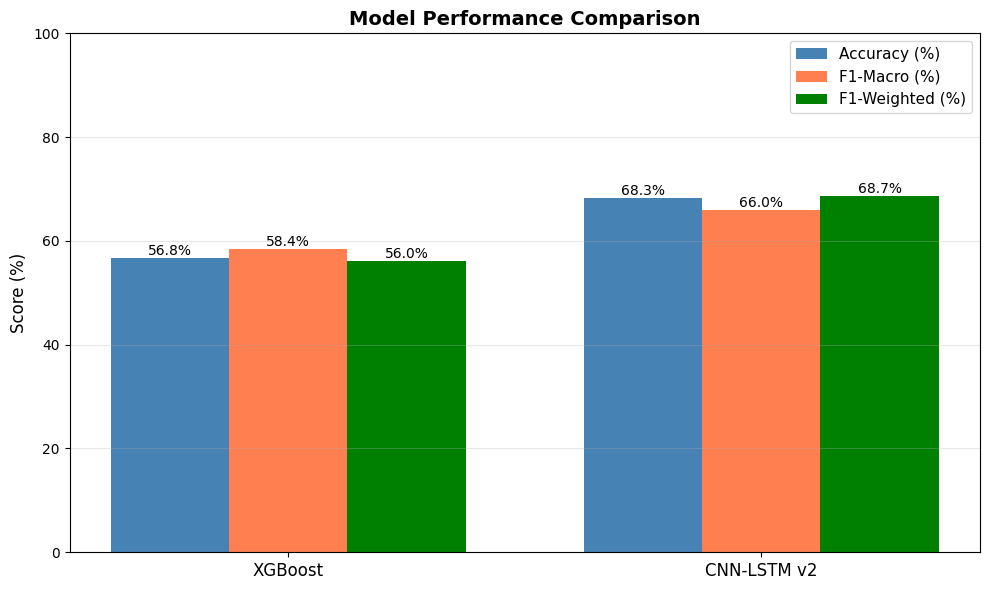

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Comparison data
models = ['XGBoost', 'CNN-LSTM v2']
accuracy = [56.76, 68.26]
f1_macro = [58.43, 66.05]
f1_weighted = [56.04, 68.65]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy (%)', color='steelblue')
bars2 = ax.bar(x, f1_macro, width, label='F1-Macro (%)', color='coral')
bars3 = ax.bar(x + width, f1_weighted, width, label='F1-Weighted (%)', color='green')

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300)
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import confusion_matrix, classification_report
import json

# Initialize SHAP's JavaScript visualization (for notebooks)
shap.initjs()

print("=" * 80)
print("WEEK 3: SHAP EXPLAINABILITY ANALYSIS")
print("=" * 80)

# ========================================================================
# LOAD DATA AND MODELS
# ========================================================================

print("\n📦 Loading preprocessed data and models...")

# Update these paths to match your dataset
DATA_PATH = '/kaggle/input/bebe-dogs-preprocessed'

# Load feature data (for XGBoost)
X_train = pd.read_csv(f'{DATA_PATH}/X_train_features.csv')
X_test = pd.read_csv(f'{DATA_PATH}/X_test_features.csv')
y_train = pd.read_csv(f'{DATA_PATH}/y_train.csv')['behavior_label'].values
y_test = pd.read_csv(f'{DATA_PATH}/y_test.csv')['behavior_label'].values

print(f"\n✅ Data loaded!")
print(f"   Training features: {X_train.shape}")
print(f"   Test features: {X_test.shape}")
print(f"   Feature names: {len(X_train.columns)}")

# Load XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('xgboost_model.json')

print(f"\n✅ XGBoost model loaded!")

# Load predictions
y_test_pred_xgb = np.load('xgboost_y_test_pred.npy')
y_test_pred_cnn = np.load('cnn_lstm_v2_y_test_pred.npy')

print(f"✅ Predictions loaded!")

# Load results
with open('xgboost_results.json', 'r') as f:
    xgb_results = json.load(f)
    
with open('cnn_lstm_v2_results.json', 'r') as f:
    cnn_results = json.load(f)

print(f"✅ Model results loaded!")

print("\n" + "=" * 80)

WEEK 3: SHAP EXPLAINABILITY ANALYSIS

📦 Loading preprocessed data and models...

✅ Data loaded!
   Training features: (349237, 35)
   Test features: (98271, 35)
   Feature names: 35

✅ XGBoost model loaded!


FileNotFoundError: [Errno 2] No such file or directory: 'xgboost_y_test_pred.npy'